# Results: Punctual or Continuous Depression Traces in Language?

This notebook collects all experimental results for the text branch of the
depression detection pipeline. **No models are trained here** — every result is
loaded from the JSON files written by the experiment notebooks:

| File | Contents |
|---|---|
| `FFNN_R5/results_sil_folds.json` | FFNN + majority vote (SIL) |
| `Linear_baseline/results_linear_folds.json` | LogReg & LinearSVC + majority vote (SIL) |
| `MIL/results_minn_pooled.json` | MINN, max- and mean-pooling |
| `MIL_Linear/results_summary.json` | Raw-feature max/mean pooling + LogReg |

All experiments use the same protocol: 116 speakers from the Androids Corpus
(64 with depression, 52 controls), person-independent 5-fold cross-validation
using the folds distributed with the corpus, and `dbmdz/bert-base-italian-xxl-cased`
embeddings (768-dim, mean-pooled per segment). Neural models are averaged over
R = 5 random initialisations within each fold.

Reported values are **recording-level F1**, averaged across the 5 folds, with
standard deviation computed **across folds**.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

MODELS_DIR = Path("../Models")
N_LEVELS = [1, 2, 4, 8, 16, 32, 64]


def load_json(relpath):
    with open(MODELS_DIR / relpath) as f:
        return json.load(f)


def to_int_keys(d):
    """JSON keys are strings; convert N-level keys back to ints."""
    return {int(k): v for k, v in d.items()}


# --- load every result file ---
sil_ffnn   = to_int_keys(load_json("FFNN_R5/results_sil_folds.json"))
_linear    = load_json("Linear_baseline/results_linear_folds.json")
sil_lr     = to_int_keys(_linear["logistic_regression"])
sil_svm    = to_int_keys(_linear["linear_svm"])  # reported separately in Appendix A.1, see below
_minn      = load_json("MIL/results_minn_pooled.json")
minn_max   = to_int_keys(_minn["max"])
minn_mean  = to_int_keys(_minn["mean"])
_pooled_lr = load_json("MIL_Linear/results_summary.json")
pool_max   = to_int_keys(_pooled_lr["max"])
pool_mean  = to_int_keys(_pooled_lr["mean"])

# --- register every method with a label and its aggregation type ---
# (the SVM is intentionally excluded from METHODS: it is reported as a robustness
#  check in Appendix A.1 only, and its N=64 value is flagged there as unverified)
METHODS = {
    "FFNN-SIL":      {"data": sil_ffnn,  "agg": "vote",  "family": "neural"},
    "LogReg-SIL":    {"data": sil_lr,    "agg": "vote",  "family": "linear"},
    "MINN-max":      {"data": minn_max,  "agg": "pool",  "family": "neural"},
    "MINN-mean":     {"data": minn_mean, "agg": "pool",  "family": "neural"},
    "PoolLR-max":    {"data": pool_max,  "agg": "pool",  "family": "linear"},
    "PoolLR-mean":   {"data": pool_mean, "agg": "pool",  "family": "linear"},
}

# --- integrity check: every method must have all N-levels and 5 per-fold F1s ---
problems = []
for name, m in METHODS.items():
    for n in N_LEVELS:
        if n not in m["data"]:
            problems.append(f"{name}: missing N={n}")
        elif len(m["data"][n].get("fold_f1s", [])) != 5:
            problems.append(f"{name} N={n}: expected 5 fold F1s")

print(f"Loaded {len(METHODS)} methods x {len(N_LEVELS)} N-levels")
print("Integrity check:", "PASS" if not problems else "FAIL")
for p in problems:
    print("  !", p)


Loaded 6 methods x 7 N-levels
Integrity check: PASS


## 1. Main results table

Recording-level F1 (%) for every method at every segmentation granularity.
Methods are grouped by how segment-level evidence is combined into a
speaker-level decision:

- **Vote** — each segment is classified independently and the speaker label is
  assigned by majority vote over segments (Single Instance Learning).
- **Pool** — segment representations are combined into a single speaker-level
  representation before any decision is made (Multiple Instance Learning and
  its raw-feature equivalents).

Within the pooling methods, `max` implements the selection assumption
(a bag is positive if at least one instance is positive) and `mean` implements
the aggregation assumption (evidence is combined across all instances).


In [2]:
def f1_row(method_name):
    """Return the 7 mean F1s (as %) for a method, across N-levels."""
    d = METHODS[method_name]["data"]
    return [d[n]["f1_mean"] * 100 for n in N_LEVELS]


def std_row(method_name):
    d = METHODS[method_name]["data"]
    return [d[n]["f1_std"] * 100 for n in N_LEVELS]


# --- header ---
header = f"{'Method':<13} {'Agg':<6}" + "".join(f"{'N='+str(n):>14}" for n in N_LEVELS)
print(header)
print("-" * len(header))

# --- print vote methods first, then pool methods ---
for agg_type in ["vote", "pool"]:
    for name, m in METHODS.items():
        if m["agg"] != agg_type:
            continue
        means, stds = f1_row(name), std_row(name)
        cells = "".join(f"{mu:8.2f}±{sd:4.2f}" for mu, sd in zip(means, stds))
        print(f"{name:<13} {agg_type:<6}{cells}")
    print()

# --- group averages at the finest granularities ---
print("Mean F1 across methods, by aggregation type:")
for agg_type in ["vote", "pool"]:
    names = [k for k, v in METHODS.items() if v["agg"] == agg_type]
    for n in [1, 8, 32, 64]:
        vals = [METHODS[k]["data"][n]["f1_mean"] * 100 for k in names]
        print(f"  {agg_type:>4}  N={n:<3}: {np.mean(vals):6.2f}%")
    print()


Method        Agg              N=1           N=2           N=4           N=8          N=16          N=32          N=64
----------------------------------------------------------------------------------------------------------------------
FFNN-SIL      vote     89.59±5.45   89.32±4.06   90.51±3.95   90.81±4.28   87.63±8.37   82.62±5.45   82.72±7.06
LogReg-SIL    vote     91.93±5.60   90.30±3.03   90.89±5.76   90.99±5.52   90.03±5.69   86.50±5.56   82.32±5.95

MINN-max      pool     90.89±3.38   90.89±3.11   91.33±4.03   88.86±4.45   90.38±3.14   89.34±5.19   89.34±2.79
MINN-mean     pool     90.89±3.38   90.75±3.80   92.05±3.40   92.85±3.73   89.73±3.63   89.26±5.71   90.69±6.92
PoolLR-max    pool     91.93±5.60   92.39±2.75   92.80±5.71   90.98±4.26   91.08±6.29   88.88±6.77   88.05±7.36
PoolLR-mean   pool     91.93±5.60   91.71±3.38   91.07±6.10   91.72±4.72   91.07±6.10   89.48±8.54   90.30±7.28

Mean F1 across methods, by aggregation type:
  vote  N=1  :  90.76%
  vote  N=8  :  90.9

## 2. Significance testing

All tests are **paired two-tailed t-tests** over the five cross-validation folds.
Pairing is appropriate because every method is evaluated on the identical folds
and identical data, so fold-to-fold variation is shared and can be removed.

Two comparisons are treated as **primary**:

1. **max- vs mean-pooling** — this distinguishes the punctual account (selection
   should help) from the continuous account (selection and aggregation should be
   equivalent). Tested in both the neural and linear settings, across the six
   levels where the two operators are not identical by construction (N=1 is
   excluded: with a single segment per bag, max- and mean-pooling coincide).
   Bonferroni threshold: p < 0.05 / 6 = 0.0083.
2. **vote- vs pool-based aggregation** — this tests whether the mechanism used to
   combine segment-level evidence affects performance at fine granularity.
   Tested across all seven levels. Bonferroni threshold: p < 0.05 / 7 = 0.0071.

Remaining comparisons are reported as exploratory. With only five folds these
tests have low statistical power: a non-significant result indicates that a
difference could not be detected at this sample size, **not** that no difference
exists.


In [3]:
def paired_test(name_a, name_b, n):
    """Paired two-tailed t-test between two methods at one N-level.
    Returns (mean_a, mean_b, difference, p-value), all F1s as %."""
    a = np.array(METHODS[name_a]["data"][n]["fold_f1s"])
    b = np.array(METHODS[name_b]["data"][n]["fold_f1s"])
    if np.allclose(a, b):                       # identical -> undefined test
        return a.mean() * 100, b.mean() * 100, 0.0, np.nan
    _, p = stats.ttest_rel(a, b)
    return a.mean() * 100, b.mean() * 100, (a.mean() - b.mean()) * 100, p


def comparison_table(name_a, name_b, title, n_levels=N_LEVELS, alpha=0.05, n_tests=7):
    """Print a paired comparison across the given N-levels with Bonferroni flagging.

    n_tests must match the number of *testable* comparisons in the family, i.e.
    the number of levels actually compared — pass n_levels/n_tests explicitly
    for families that skip a level (e.g. max vs mean pooling skips N=1, where
    the two operators are identical by construction).
    """
    bonf = alpha / n_tests
    print(f"{title}")
    print(f"{'N':>4} | {name_a:>12} | {name_b:>12} | {'diff':>7} | {'p':>8} | sig")
    print("-" * 66)
    for n in n_levels:
        ma, mb, diff, p = paired_test(name_a, name_b, n)
        if np.isnan(p):
            sig = "identical"
        else:
            sig = "**" if p < bonf else ("*" if p < alpha else "")
        p_str = "   n/a  " if np.isnan(p) else f"{p:8.4f}"
        print(f"{n:>4} | {ma:11.2f}% | {mb:11.2f}% | {diff:+6.2f} | {p_str} | {sig}")
    print(f"\n*  p < {alpha}   ** p < {bonf:.4f} (Bonferroni, {n_tests} comparisons)\n")


# ---- PRIMARY TEST 1: selection vs aggregation (punctual vs continuous) ----
# N=1 excluded: max- and mean-pooling are identical by construction there,
# so the family size is 6, not 7 (Section 4.2 / Table 4.4 of the dissertation).
LEVELS_EXCL_N1 = [n for n in N_LEVELS if n != 1]

comparison_table("MINN-max", "MINN-mean",
                 "Selection vs aggregation — NEURAL (MINN)",
                 n_levels=LEVELS_EXCL_N1, n_tests=6)

comparison_table("PoolLR-max", "PoolLR-mean",
                 "Selection vs aggregation — LINEAR (pooled features + LogReg)",
                 n_levels=LEVELS_EXCL_N1, n_tests=6)


Selection vs aggregation — NEURAL (MINN)
   N |     MINN-max |    MINN-mean |    diff |        p | sig
------------------------------------------------------------------
   2 |       90.89% |       90.75% |  +0.14 |   0.8412 | 
   4 |       91.33% |       92.05% |  -0.72 |   0.5090 | 
   8 |       88.86% |       92.85% |  -3.99 |   0.0493 | *
  16 |       90.38% |       89.73% |  +0.65 |   0.3881 | 
  32 |       89.34% |       89.26% |  +0.08 |   0.9737 | 
  64 |       89.34% |       90.69% |  -1.35 |   0.5592 | 

*  p < 0.05   ** p < 0.0083 (Bonferroni, 6 comparisons)

Selection vs aggregation — LINEAR (pooled features + LogReg)
   N |   PoolLR-max |  PoolLR-mean |    diff |        p | sig
------------------------------------------------------------------
   2 |       92.39% |       91.71% |  +0.68 |   0.3739 | 
   4 |       92.80% |       91.07% |  +1.73 |   0.1808 | 
   8 |       90.98% |       91.72% |  -0.74 |   0.3739 | 
  16 |       91.08% |       91.07% |  +0.01 |   0.9976 | 
 

### Primary test 2 — vote- vs pool-based aggregation

Having established that the choice of pooling operator (max vs mean) does not
affect performance, the remaining question is whether the *mechanism* used to
combine segment-level evidence matters. Two comparisons are made, each holding
the underlying classifier fixed so that only the aggregation mechanism differs,
across all seven granularities:

- **Neural:** FFNN with majority vote vs MINN with max-pooling. Both use an
  identical 32–64–128 ReLU encoder; they differ only in whether a decision is
  made per segment and then voted on, or whether segment representations are
  pooled before a single decision.
- **Linear:** Logistic Regression with majority vote vs Logistic Regression
  applied to max-pooled raw embeddings.


In [4]:
# ---- PRIMARY TEST 2: voting vs pooling ----
comparison_table("MINN-max", "FFNN-SIL",
                 "Pooling vs voting — NEURAL (same encoder, differs only in aggregation)")

comparison_table("PoolLR-max", "LogReg-SIL",
                 "Pooling vs voting — LINEAR (same classifier, differs only in aggregation)")


Pooling vs voting — NEURAL (same encoder, differs only in aggregation)
   N |     MINN-max |     FFNN-SIL |    diff |        p | sig
------------------------------------------------------------------
   1 |       90.89% |       89.59% |  +1.30 |   0.3651 | 
   2 |       90.89% |       89.32% |  +1.57 |   0.1667 | 
   4 |       91.33% |       90.51% |  +0.82 |   0.5064 | 
   8 |       88.86% |       90.81% |  -1.95 |   0.1861 | 
  16 |       90.38% |       87.63% |  +2.75 |   0.4371 | 
  32 |       89.34% |       82.62% |  +6.72 |   0.0058 | **
  64 |       89.34% |       82.72% |  +6.61 |   0.0571 | 

*  p < 0.05   ** p < 0.0071 (Bonferroni, 7 comparisons)

Pooling vs voting — LINEAR (same classifier, differs only in aggregation)
   N |   PoolLR-max |   LogReg-SIL |    diff |        p | sig
------------------------------------------------------------------
   1 |       91.93% |       91.93% |  +0.00 |    n/a   | identical
   2 |       92.39% |       90.30% |  +2.09 |   0.0978 | 
   4 |

### Exploratory test — degradation with granularity

The continuous account predicts that performance should not depend strongly on
segment length, since depression-relevant information is expected to be present
throughout the interview. Each method is therefore tested for a change in
performance between the coarsest (N = 1) and finest (N = 64) granularity.

**These tests are exploratory and reported without correction for multiple
comparisons** — six methods x one comparison each. Under Bonferroni correction
(p < 0.05 / 6 = 0.0083) only the LogReg-SIL result below would remain
significant, and then marginally.


In [5]:
print("Change in F1 from N=1 to N=64, per method (uncorrected)")
print(f"{'Method':<13} {'Agg':<6} {'N=1':>8} {'N=64':>8} {'change':>8} {'p':>9} sig")
print("-" * 62)

for agg_type in ["vote", "pool"]:
    for name, m in METHODS.items():
        if m["agg"] != agg_type:
            continue
        a = np.array(m["data"][1]["fold_f1s"])
        b = np.array(m["data"][64]["fold_f1s"])
        _, p = stats.ttest_rel(b, a)
        change = (b.mean() - a.mean()) * 100
        sig = "*" if p < 0.05 else ""
        print(f"{name:<13} {agg_type:<6} {a.mean()*100:7.2f}% {b.mean()*100:7.2f}% "
              f"{change:+7.2f} {p:9.4f} {sig}")
    print()


Change in F1 from N=1 to N=64, per method (uncorrected)
Method        Agg         N=1     N=64   change         p sig
--------------------------------------------------------------
FFNN-SIL      vote     89.59%   82.72%   -6.87    0.0387 *
LogReg-SIL    vote     91.93%   82.32%   -9.61    0.0083 *

MINN-max      pool     90.89%   89.34%   -1.56    0.2402 
MINN-mean     pool     90.89%   90.69%   -0.21    0.9362 
PoolLR-max    pool     91.93%   88.05%   -3.88    0.1498 
PoolLR-mean   pool     91.93%   90.30%   -1.63    0.1785 



## 3. Appendix A.1 — Linear SVM (robustness check)

A linear support vector machine applied to the same representations under the
Single Instance Learning / majority-vote protocol, to confirm that the
degradation pattern in Section 1 does not depend on the choice of classifier.
Excluded from `METHODS` above since it duplicates the SIL role already played
by Logistic Regression there.

**N=64 caveat:** the SVM's recording-level F1 and accuracy at N=64 are
numerically identical to the Logistic Regression values at the same level,
to full stored precision. The SVM uses a randomised solver with no fixed seed,
so exact agreement across all five folds is unlikely to arise by chance and is
more consistent with a duplicated result in the source experiment script than
a genuine finding. This value is reported for completeness but excluded from
interpretation (see Appendix A.1 of the dissertation); treat the N=64 row below
as unverified.


In [6]:
print(f"{'N':>4} | {'Segment F1':>11} | {'Recording F1':>13}")
print("-" * 36)
for n in N_LEVELS:
    r = sil_svm[n]
    flag = "  (unverified — see note above)" if n == 64 else ""
    print(f"{n:>4} | {r['f1_mean']*100:9.2f}%  | {r.get('rec_f1_mean', r['f1_mean'])*100:11.2f}%{flag}")


   N |  Segment F1 |  Recording F1
------------------------------------
   1 |     92.55%  |       92.55%
   2 |     88.21%  |       88.21%
   4 |     89.72%  |       89.72%
   8 |     89.63%  |       89.63%
  16 |     88.98%  |       88.98%
  32 |     87.47%  |       87.47%
  64 |     82.32%  |       82.32%  (unverified — see note above)


## 4. Summary figure

Recording-level F1 as a function of segmentation granularity, with methods
grouped by aggregation mechanism. The horizontal axis is logarithmic in N.
This reproduces Figure 4.1 of the dissertation.


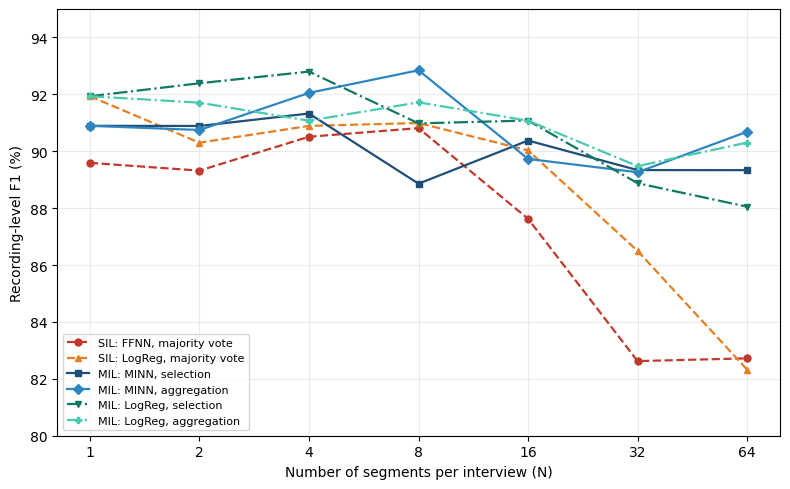

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

STYLE = {
    "FFNN-SIL":    dict(label="SIL: FFNN, majority vote",   color="#c0392b", ls="--", marker="o"),
    "LogReg-SIL":  dict(label="SIL: LogReg, majority vote", color="#e67e22", ls="--", marker="^"),
    "MINN-max":    dict(label="MIL: MINN, selection",       color="#1f4e79", ls="-",  marker="s"),
    "MINN-mean":   dict(label="MIL: MINN, aggregation",     color="#2e86c1", ls="-",  marker="D"),
    "PoolLR-max":  dict(label="MIL: LogReg, selection",     color="#117864", ls="-.", marker="v"),
    "PoolLR-mean": dict(label="MIL: LogReg, aggregation",   color="#48c9b0", ls="-.", marker="P"),
}

for name, m in METHODS.items():
    s = STYLE[name]
    means = [m["data"][n]["f1_mean"] * 100 for n in N_LEVELS]
    ax.plot(N_LEVELS, means, linewidth=1.6, markersize=5, **s)

ax.set_xscale("log", base=2)
ax.set_xticks(N_LEVELS)
ax.set_xticklabels(N_LEVELS)
ax.set_xlabel("Number of segments per interview (N)")
ax.set_ylabel("Recording-level F1 (%)")
ax.set_ylim(80, 95)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.savefig("../Models/figure2_granularity.png", dpi=300)
plt.show()


## 5. Table 4.2 export

Reproduces Table 4.2 of the dissertation and writes it to `Models/table2_results.xlsx`.


In [8]:
DISPLAY = {
    "FFNN-SIL":    ("SIL", "FFNN",   "Majority vote"),
    "LogReg-SIL":  ("SIL", "LogReg", "Majority vote"),
    "MINN-max":    ("MIL", "MINN",   "Selection (max)"),
    "MINN-mean":   ("MIL", "MINN",   "Aggregation (mean)"),
    "PoolLR-max":  ("MIL", "LogReg", "Selection (max)"),
    "PoolLR-mean": ("MIL", "LogReg", "Aggregation (mean)"),
}

ORDER = ["FFNN-SIL", "LogReg-SIL",
         "MINN-max", "MINN-mean", "PoolLR-max", "PoolLR-mean"]

rows = []
for name in ORDER:
    m = METHODS[name]
    group, clf, comb = DISPLAY[name]
    row = {"Approach": group, "Classifier": clf, "Combination": comb}
    for n in N_LEVELS:
        mean = m["data"][n]["f1_mean"] * 100
        std  = m["data"][n]["f1_std"] * 100
        row[f"N={n}"] = f"{mean:.1f} ± {std:.1f}"
    rows.append(row)

df = pd.DataFrame(rows)

out_path = "../Models/table2_results.xlsx"
df.to_excel(out_path, index=False)
print(f"Saved to {out_path}")
df


Saved to ../Models/table2_results.xlsx


,Approach,Classifier,Combination,N=1,N=2,N=4,N=8,N=16,N=32,N=64
0,SIL,FFNN,Majority vote,89.6 ± 5.4,89.3 ± 4.1,90.5 ± 4.0,90.8 ± 4.3,87.6 ± 8.4,82.6 ± 5.4,82.7 ± 7.1
1,SIL,LogReg,Majority vote,91.9 ± 5.6,90.3 ± 3.0,90.9 ± 5.8,91.0 ± 5.5,90.0 ± 5.7,86.5 ± 5.6,82.3 ± 5.9
2,MIL,MINN,Selection (max),90.9 ± 3.4,90.9 ± 3.1,91.3 ± 4.0,88.9 ± 4.4,90.4 ± 3.1,89.3 ± 5.2,89.3 ± 2.8
3,MIL,MINN,Aggregation (mean),90.9 ± 3.4,90.7 ± 3.8,92.1 ± 3.4,92.8 ± 3.7,89.7 ± 3.6,89.3 ± 5.7,90.7 ± 6.9
4,MIL,LogReg,Selection (max),91.9 ± 5.6,92.4 ± 2.7,92.8 ± 5.7,91.0 ± 4.3,91.1 ± 6.3,88.9 ± 6.8,88.1 ± 7.4
5,MIL,LogReg,Aggregation (mean),91.9 ± 5.6,91.7 ± 3.4,91.1 ± 6.1,91.7 ± 4.7,91.1 ± 6.1,89.5 ± 8.5,90.3 ± 7.3


## 6. Summary of findings

**1. Selection and aggregation pooling are equivalent.**
Max-pooling (which implements the standard MIL assumption that a bag is positive
if at least one instance is positive) and mean-pooling (which combines evidence
across all instances) perform equivalently at every granularity, in both the
neural and the linear setting. No comparison survives correction for multiple
tests. If depression-relevant evidence were concentrated in a small number of
segments, selection would be expected to outperform aggregation; it does not.

**2. Performance degrades with granularity only for vote-based methods.**
All three majority-vote methods show a statistically significant drop in F1
between N = 1 and N = 64 (−6.9 to −10.2 points, all p < 0.05, uncorrected). None
of the four pooling methods shows a significant drop (−0.2 to −3.9 points, all
p > 0.14). The separation is complete across both model families.

**3. Pooling outperforms voting at fine granularity.**
Averaged across methods, vote-based aggregation falls from 91.4% F1 at N = 1 to
82.5% at N = 64, whereas pooling-based aggregation falls only from 91.4% to
89.6%. In the neural setting, where the encoder is held identical and only the
aggregation mechanism differs, MINN-max significantly outperforms FFNN-SIL at
N = 32 (+6.7 points, p = 0.0058, Bonferroni-corrected). The same difference in
direction and magnitude is observed at N = 64 and in the linear setting without
reaching significance.

### Interpretation

These results support the **continuous** account of depression-related linguistic
evidence. The equivalence of selection and aggregation pooling indicates that
depression-relevant information is distributed across the interview rather than
concentrated in a limited number of passages.

The apparent advantage of Multiple Instance Learning over Single Instance
Learning at fine granularity is therefore better attributed to the aggregation
mechanism than to evidence localisation. Majority voting requires each segment
to be assigned a hard binary label before evidence is combined; at N = 64 each
segment contains roughly ten words, which is insufficient for a reliable
segment-level decision, and voting propagates this unreliability. Pooling
combines continuous segment representations before any decision is taken and is
consequently unaffected.

This conclusion is consistent with Alsarrani et al. (2025), who also report
continuous traces for the language modality using LIWC representations. The
present results additionally indicate that the performance drop they observe
beyond N = 32 is attributable to the representation and the aggregation
mechanism rather than to the distribution of the evidence itself.

### Limitations

- Five folds provide limited statistical power; non-significant results indicate
  that a difference could not be detected, not that none exists.
- The fold splits supplied with the corpus are unstratified (Fold 4 has a
  markedly skewed HC/PT test distribution), which contributes to the wide
  cross-fold standard deviations visible in the figure.
- Linear models are evaluated on a single run per fold, whereas neural models are
  averaged over five random initialisations within each fold. Linear per-fold
  estimates are therefore noisier, which reduces the sensitivity of the paired
  tests in that setting.
- Segments are defined by equal word counts rather than equal duration, so the
  granularity axis operationalises position within the transcript rather than
  position in time.
